# Setup

In [5]:
from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE_BASE           = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data"
PROJECT_BASE         = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title"
EMBEDDINGS_PKL       = f"{DRIVE_BASE}/embeddings.pkl"
CLUSTERS_OUTPUT_DIR  = f"{PROJECT_BASE}/new clusters"
REPO_DIR             = "/content/RecsysUpgrade"

os.makedirs(CLUSTERS_OUTPUT_DIR, exist_ok=True)
print("Paths configured.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


In [6]:
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/siddmohanty111/RecsysUpgrade.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

print("Repo ready:", REPO_DIR)

Already up to date.
Repo ready: /content/RecsysUpgrade


In [7]:
%pip install -r {REPO_DIR}/requirements.txt

# Imports

In [8]:
import os
import random
import importlib.util
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skfuzzy import cmeans
from sklearn.manifold import TSNE

# Fix Pandas Version

In [9]:
# # @title
# import subprocess, sys

# # Upgrade pandas to latest
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pandas", "-q"])

# # Restart runtime so the new pandas version is actually loaded
# import os
# os.kill(os.getpid(), 9)  # Forces a runtime restart — re-run all cells after this

In [10]:
cluster_alts_path = os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "cluster_alts.py")

with open(cluster_alts_path, 'r') as f:
    content = f.read()

# Replace the incorrect import statement
content = content.replace('from skfuzzy import cmeans, cmeans_predict', 'import skfuzzy as fuzz')

# Replace function calls
content = content.replace('cmeans(', 'fuzz.cmeans(')
content = content.replace('cmeans_predict(', 'fuzz.cmeans_predict(')

with open(cluster_alts_path, 'w') as f:
    f.write(content)

print(f"Successfully modified {cluster_alts_path} to correct skfuzzy imports.")


Successfully modified /content/RecsysUpgrade/PlaylistRecsysUpgrade/clustering/cluster_alts.py to correct skfuzzy imports.


In [11]:
spec = importlib.util.spec_from_file_location(
    "cluster_alts",
    os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "cluster_alts.py"),
)
cluster_alts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cluster_alts)

print("cluster_alts loaded.")


cluster_alts loaded.


# Load Embeddings

In [12]:
with open(EMBEDDINGS_PKL, 'rb') as f:
    data = pickle.load(f)

In [13]:
print("Full DataFrame shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())

Full DataFrame shape: (1000000, 4)
Columns: ['playlist_title', 'title_embedding', 'playlist_tracks', 'tracks_embedding']
     playlist_title                                    title_embedding  \
0        throwbacks  [0.011216642, 0.0033928207, 0.003417922, -0.01...   
1  awesome playlist  [-0.08927007, -0.09901914, -0.0293388, -0.0857...   
2            korean  [-0.049768448, 0.05802605, 0.023397932, 0.0232...   
3               mat  [-0.023064643, 0.022735357, -0.058358226, 0.00...   
4               90s  [-0.047616515, 0.06071275, -0.033675063, -0.03...   

                                     playlist_tracks  \
0  [Lose Control (feat. Ciara & Fat Man Scoop), T...   
1  [Eye of the Tiger, Libera Me From Hell (Tengen...   
2  [Like You, GOOD (feat. ELO), Inferiority Compl...   
3  [Danse macabre, Piano concerto No. 2 in G Mino...   
4  [Tonight, Tonight, Wonderwall - Remastered, I ...   

                                    tracks_embedding  
0  [-0.08528523, 0.038696438, 0.015848912,

# Perform Fuzzy Clustering on the Playlist titles

In [14]:
NUM_CLUSTERS = 50

fkmeans_titles_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_title_clusters.pkl")

print("Preparing title embeddings...")
# Stack list of arrays into a 2D numpy array and transpose to (features, n_samples)
title_embeddings = np.stack(data['title_embedding'].values)
data_for_cmeans = title_embeddings.T

print("Fitting Fuzzy K-Means on titles...")
# cmeans returns: cntr, u, u0, d, jm, p, fpc
cntr, u, u0, d, jm, p, fpc = cmeans(data_for_cmeans, NUM_CLUSTERS, 2, error=0.005, maxiter=1000)

# 'u' is shape (NUM_CLUSTERS, n_samples). Transpose to get (n_samples, NUM_CLUSTERS)
title_cluster_probs = u.T

# Create a dataframe keeping the playlist identifier and its cluster probabilities
title_clusters_df = pd.DataFrame({
    'playlist_title': data['playlist_title'],
    'title_cluster_probs': list(title_cluster_probs)
})

title_clusters_df.to_pickle(fkmeans_titles_output)
print(f"Saved title cluster probabilities to {fkmeans_titles_output}")
display(title_clusters_df.head())

Preparing title embeddings...
Fitting Fuzzy K-Means on titles...
Saved title cluster probabilities to /content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/new clusters/fkmeans_title_clusters.pkl


,playlist_title,title_cluster_probs
0,throwbacks,"[0.019999954016124703, 0.019999956113776276, 0..."
1,awesome playlist,"[0.02000013356999115, 0.02000014844290938, 0.0..."
2,korean,"[0.019999992891892783, 0.01999998588333972, 0...."
3,mat,"[0.01999996637957206, 0.0199999659375002, 0.02..."
4,90s,"[0.019999985643542984, 0.019999966513753083, 0..."


# Perform Fuzzy Clustering on the Mean-pooled Track embeddings for each Playlist

In [15]:
NUM_CLUSTERS = 50

fkmeans_tracks_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_tracks_clusters.pkl")

print("Preparing track embeddings...")
# Stack list of arrays into a 2D numpy array and transpose to (features, n_samples)
tracks_embeddings = np.stack(data['tracks_embedding'].values)
data_for_cmeans = tracks_embeddings.T

print("Fitting Fuzzy K-Means on tracks...")
# cmeans returns: cntr, u, u0, d, jm, p, fpc
cntr, u, u0, d, jm, p, fpc = cmeans(data_for_cmeans, NUM_CLUSTERS, 2, error=0.005, maxiter=1000)

# 'u' is shape (NUM_CLUSTERS, n_samples). Transpose to get (n_samples, NUM_CLUSTERS)
tracks_cluster_probs = u.T

# Create a dataframe keeping the playlist identifier and its cluster probabilities
tracks_clusters_df = pd.DataFrame({
    'playlist_title': data['playlist_title'],
    'tracks_cluster_probs': list(tracks_cluster_probs)
})

tracks_clusters_df.to_pickle(fkmeans_tracks_output)
print(f"Saved tracks cluster probabilities to {fkmeans_tracks_output}")
display(tracks_clusters_df.head())

Preparing track embeddings...
Fitting Fuzzy K-Means on tracks...
Saved tracks cluster probabilities to /content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/new clusters/fkmeans_tracks_clusters.pkl


,playlist_title,tracks_cluster_probs
0,throwbacks,"[0.01999945014465863, 0.020000578376690312, 0...."
1,awesome playlist,"[0.019999853491703835, 0.020000018658121947, 0..."
2,korean,"[0.020000100489518693, 0.01999985259348173, 0...."
3,mat,"[0.01999807724940751, 0.020001448032271947, 0...."
4,90s,"[0.020000294087801695, 0.019999841893132034, 0..."


# Compare Clusters using KL Divergence

In [16]:
import pandas as pd
import os
import numpy as np
from scipy.stats import entropy

# Redefine paths in case they were lost from memory
CLUSTERS_OUTPUT_DIR = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Track vs Title/new clusters"
fkmeans_titles_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_title_clusters.pkl")
fkmeans_tracks_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_tracks_clusters.pkl")

print("Loading cluster probabilities...")
title_clusters_df = pd.read_pickle(fkmeans_titles_output)
tracks_clusters_df = pd.read_pickle(fkmeans_tracks_output)

print("Converting to numpy arrays for efficient computation...")
# Convert the lists of probabilities into 2D numpy arrays
p_matrix = np.vstack(title_clusters_df['title_cluster_probs'].values)
q_matrix = np.vstack(tracks_clusters_df['tracks_cluster_probs'].values)

# Free up memory by dropping the original lists if we want, or just delete tracks_clusters_df
del tracks_clusters_df

print("Shapes:", p_matrix.shape, q_matrix.shape)

Loading cluster probabilities...
Converting to numpy arrays for efficient computation...
Shapes: (1000000, 50) (1000000, 50)


In [17]:
print("Computing KL Divergence...")
# Add epsilon and normalize
epsilon = 1e-10
p_matrix = np.clip(p_matrix, epsilon, 1.0)
q_matrix = np.clip(q_matrix, epsilon, 1.0)

p_matrix /= np.sum(p_matrix, axis=1, keepdims=True)
q_matrix /= np.sum(q_matrix, axis=1, keepdims=True)

# Vectorized KL divergence calculation (scipy.stats.entropy calculates over axis=0 by default, so we specify axis=1)
kl_divergences = entropy(p_matrix, q_matrix, axis=1)

# Add the results back to the title DataFrame
title_clusters_df['kl_divergence'] = kl_divergences
merged_df = title_clusters_df # Rename for the next cell to work

print("KL Divergence computation complete.")
display(merged_df[['playlist_title', 'kl_divergence']].head())

Computing KL Divergence...
KL Divergence computation complete.


,playlist_title,kl_divergence
0,throwbacks,1.381916e-10
1,awesome playlist,3.139519e-11
2,korean,8.774941e-12
3,mat,1.219104e-09
4,90s,3.216197e-11


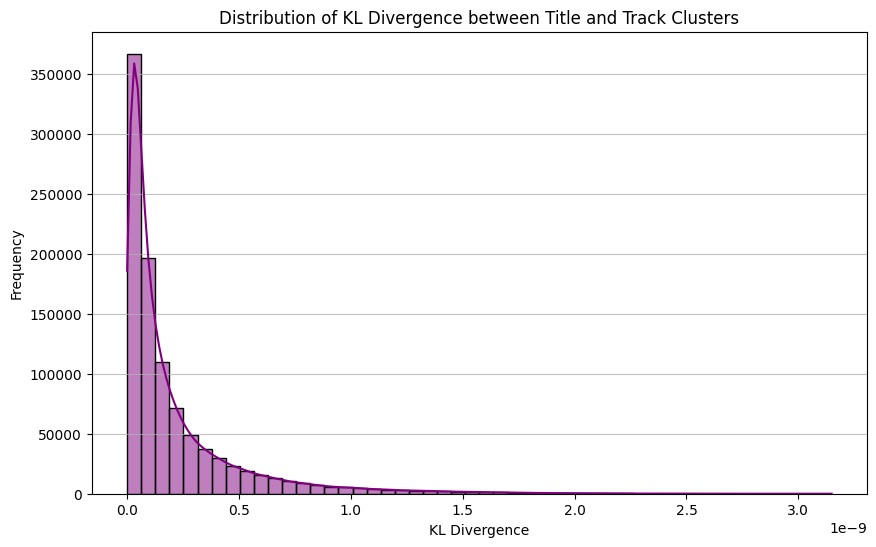

Top 5 Playlists with HIGHEST KL Divergence (Most Mismatched):


,playlist_title,kl_divergence
391708,good songs.,3.149132e-09
916170,moodz,2.951567e-09
574337,james,2.923654e-09
403717,2010's,2.921966e-09
223404,danielle,2.915850e-09



Top 5 Playlists with LOWEST KL Divergence (Most Matched):


,playlist_title,kl_divergence
83497,mashups,1.313920e-13
174824,setlist,2.868627e-13
201995,covers,2.873380e-13
903327,slaylist,3.058807e-13
309090,young and beautiful,3.211068e-13


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(merged_df['kl_divergence'], bins=50, kde=True, color='purple')
plt.title('Distribution of KL Divergence between Title and Track Clusters')
plt.xlabel('KL Divergence')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Show the playlists with the highest and lowest KL divergence
print("Top 5 Playlists with HIGHEST KL Divergence (Most Mismatched):")
display(merged_df.nlargest(5, 'kl_divergence')[['playlist_title', 'kl_divergence']])

print("\nTop 5 Playlists with LOWEST KL Divergence (Most Matched):")
display(merged_df.nsmallest(5, 'kl_divergence')[['playlist_title', 'kl_divergence']])

# Cluster-Level KL Divergence Analysis

Assigning playlists to dominant clusters...

Top 10 Clusters with LOWEST Median KL Divergence (Most Matched):


,dominant_cluster,mean_kl,median_kl,playlist_count
34,41,4.509976e-11,2.038985e-11,85
15,17,1.568136e-10,2.771039e-11,31
23,26,1.112917e-10,2.950369e-11,229
25,29,1.362133e-10,4.309084e-11,31
14,16,1.468296e-10,4.942978e-11,898
1,2,1.217271e-10,4.998385e-11,355
9,10,1.399729e-10,5.436889e-11,954
6,7,1.447700e-10,5.714885e-11,818
31,36,1.526362e-10,6.568546e-11,60
3,4,1.602916e-10,7.011854e-11,150



Top 10 Clusters with HIGHEST Median KL Divergence (Most Mismatched):


,dominant_cluster,mean_kl,median_kl,playlist_count
35,42,2.505415e-10,1.228947e-10,58
12,14,3.045854e-10,1.304447e-10,301
39,47,3.113801e-10,1.339963e-10,227
18,21,2.882844e-10,1.350894e-10,60
41,49,2.742656e-10,1.352072e-10,8612
8,9,2.489091e-10,1.406056e-10,54
4,5,2.262281e-10,1.413087e-10,5039
24,28,3.705899e-10,1.675404e-10,7
19,22,2.489565e-10,1.798675e-10,248
2,3,2.670953e-10,2.575478e-10,7


/tmp/ipykernel_16851/3102279116.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


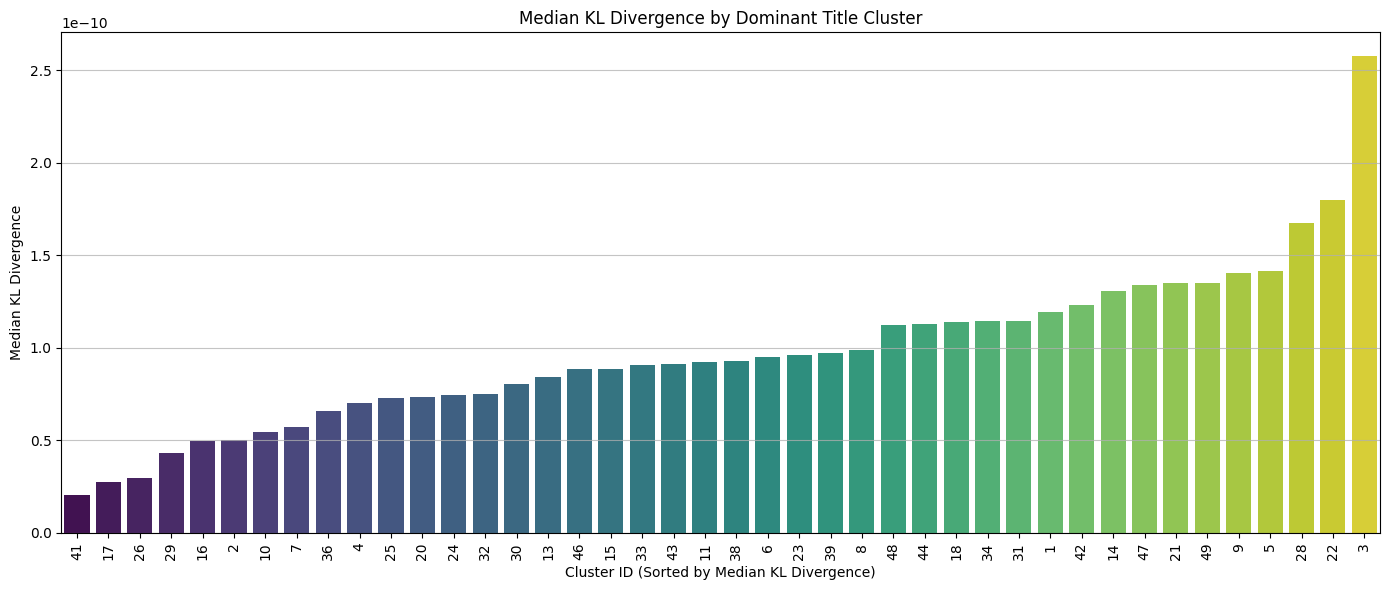

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Assigning playlists to dominant clusters...")
# Extract probabilities and find the index of the max probability (dominant cluster)
probs = np.vstack(merged_df['title_cluster_probs'].values)
merged_df['dominant_cluster'] = np.argmax(probs, axis=1)

# Group by the dominant cluster and compute statistics for KL divergence
cluster_kl_stats = merged_df.groupby('dominant_cluster')['kl_divergence'].agg(
    mean_kl='mean',
    median_kl='median',
    playlist_count='count'
).reset_index()

# Sort by median KL divergence to highlight the clusters with the lowest divergence
cluster_kl_stats = cluster_kl_stats.sort_values(by='median_kl')

print("\nTop 10 Clusters with LOWEST Median KL Divergence (Most Matched):")
display(cluster_kl_stats.head(10))

print("\nTop 10 Clusters with HIGHEST Median KL Divergence (Most Mismatched):")
display(cluster_kl_stats.tail(10))

# Visualize
plt.figure(figsize=(14, 6))
sns.barplot(
    x='dominant_cluster',
    y='median_kl',
    data=cluster_kl_stats,
    order=cluster_kl_stats['dominant_cluster'],
    palette='viridis'
)
plt.title('Median KL Divergence by Dominant Title Cluster')
plt.xlabel('Cluster ID (Sorted by Median KL Divergence)')
plt.ylabel('Median KL Divergence')
# Ensure all 50 clusters are shown on x-axis
plt.xticks(ticks=range(len(cluster_kl_stats)), labels=cluster_kl_stats['dominant_cluster'], rotation=90)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()